# Results Analysis
## Emotion Recognition from Abstract Art
### F1-Macro, AUC-ROC, Confusion Matrices, McNemar's Test

In [16]:
# Imports
import torch
import numpy as np
import pickle
import json
import sys
sys.path.append('..')

from src.preprocessing import load_data, get_splits, get_class_weights
from src.dataset import get_dataloaders
from src.model_vit import ViTClassifier
from src.model_benchmarks import (
    get_resnet50, get_feature_extractor,
    extract_features, extract_handcrafted_features
)
from src.evaluate import (
    evaluate, get_predictions, compute_metrics,
    print_classification_report, plot_training_curves,
    plot_benchmark_comparison, plot_confusion_matrices,
    run_mcnemar_test, EMOTION_CLASSES
)

In [17]:
# Device and Data
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

df, le = load_data("../data/dataset_final.csv")
train_df, val_df, test_df = get_splits(df, subset_size=3000)
class_weights = get_class_weights(train_df, device)
IMAGE_DIR = "../data/images"
train_loader, val_loader, test_loader = get_dataloaders(
    train_df, val_df, test_df, IMAGE_DIR
)
print(f"Test samples: {len(test_df)}")

Using device: mps
Test samples: 300


In [18]:
with open('../models/best_vit_model_history.json') as f:
    vit_history = json.load(f)

with open('../models/best_resnet50_history.json') as f:
    resnet_history = json.load(f)

print("ViT best val acc:", max(vit_history['val_acc']))
print("ResNet-50 best val acc:", max(resnet_history['val_acc']))

ViT best val acc: 0.20333333333333334
ResNet-50 best val acc: 0.24


## Training Curves
Loss and accuracy curves for ViT and ResNet-50.

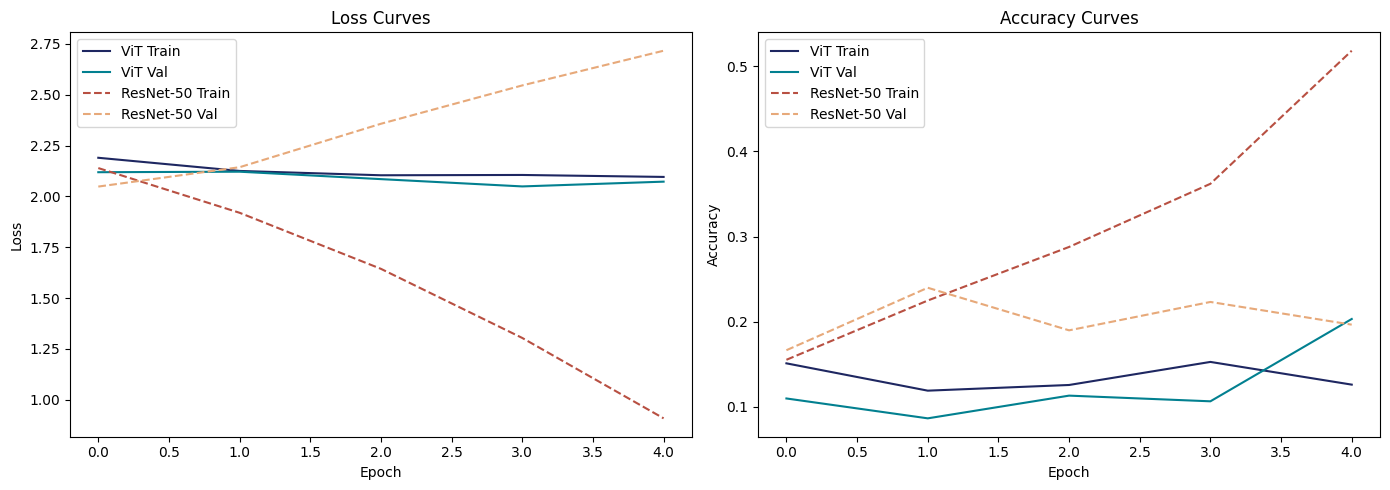

In [19]:
# Plot Training Curves
plot_training_curves(
    histories={'ViT': vit_history, 'ResNet-50': resnet_history},
    save_path="../results/training_curves.png"
)

In [20]:
# ViT Predictions
vit_model = ViTClassifier(
    image_size=224, patch_size=16, num_classes=8,
    embed_dim=256, depth=4, num_heads=8, mlp_ratio=2, dropout=0.1
).to(device)
vit_model.load_state_dict(
    torch.load("../models/best_vit_model.pth", map_location=device)
)

preds_vit, probs_vit, all_labels = get_predictions(vit_model, test_loader, device)
del vit_model
print(f"ViT predictions: {len(preds_vit)} samples")

ViT predictions: 300 samples


In [21]:
# ResNet-50 Predictions
resnet_model = get_resnet50(num_classes=8).to(device)
resnet_model.load_state_dict(
    torch.load("../models/best_resnet50.pth", map_location=device)
)

preds_resnet, probs_resnet, _ = get_predictions(resnet_model, test_loader, device)
del resnet_model
print(f"ResNet-50 predictions: {len(preds_resnet)} samples")

ResNet-50 predictions: 300 samples


In [22]:
# SVM Predictions
with open('../models/svm_model.pkl', 'rb') as f:
    svm_data = pickle.load(f)
svm_model = svm_data['svm']
scaler = svm_data['scaler']

feature_extractor = get_feature_extractor(device)
X_test, _ = extract_features(test_loader, feature_extractor, device)
X_test_scaled = scaler.transform(X_test)
preds_svm = np.array(svm_model.predict(X_test_scaled))
probs_svm = np.array(svm_model.predict_proba(X_test_scaled))

del feature_extractor, X_test, X_test_scaled
print(f"SVM predictions: {len(preds_svm)} samples")

SVM predictions: 300 samples


In [23]:
# Naive Bayes Predictions
with open('../models/nb_model.pkl', 'rb') as f:
    nb_model = pickle.load(f)

X_test_hc, _ = extract_handcrafted_features(test_df, IMAGE_DIR)
preds_nb = np.array(nb_model.predict(X_test_hc))
probs_nb = np.array(nb_model.predict_proba(X_test_hc))

del nb_model, X_test_hc
print(f"Naive Bayes predictions: {len(preds_nb)} samples")

100%|██████████| 300/300 [00:35<00:00,  8.40it/s]

Naive Bayes predictions: 300 samples


## Results Summary
F1-Macro and AUC-ROC on test set for all four models.

In [24]:
# Compute Metrics
results = {}
print(f"{'Model':<20} {'Val Acc':<12} {'F1-Macro':<12} {'AUC-ROC'}")
print("=" * 56)

for name, preds, probs, val_acc in [
    ('ViT', preds_vit, probs_vit, max(vit_history['val_acc'])),
    ('ResNet-50', preds_resnet, probs_resnet, max(resnet_history['val_acc'])),
    ('SVM', preds_svm, probs_svm, 0.3433),
    ('Naive Bayes', preds_nb, probs_nb, 0.1633),
]:
    metrics = compute_metrics(all_labels, preds, probs)
    results[name] = {'val_acc': val_acc, **metrics}
    print(f"{name:<20} {val_acc:<12.4f} {metrics['f1_macro']:<12.4f} {metrics['auc_roc']:.4f}")

Model                Val Acc      F1-Macro     AUC-ROC
ViT                  0.2033       0.0628       0.5066
ResNet-50            0.2400       0.1509       0.5676
SVM                  0.3433       0.1803       0.5584
Naive Bayes          0.1633       0.1385       0.5171


In [25]:
# ViT Classification Report
print("ViT — Per-class Classification Report:")
print_classification_report(all_labels, preds_vit)

ViT — Per-class Classification Report:
              precision    recall  f1-score   support

   amusement       0.00      0.00      0.00         6
       anger       0.10      0.05      0.07        20
         awe       0.00      0.00      0.00        10
 contentment       0.07      0.08      0.07        26
     disgust       0.00      0.00      0.00        45
  excitement       0.03      0.44      0.05         9
        fear       0.22      0.17      0.19        72
     sadness       0.35      0.07      0.12       112

    accuracy                           0.09       300
   macro avg       0.10      0.10      0.06       300
weighted avg       0.20      0.09      0.10       300



## Benchmark Comparison
All four models compared on Validation Accuracy, F1-Macro, and AUC-ROC.

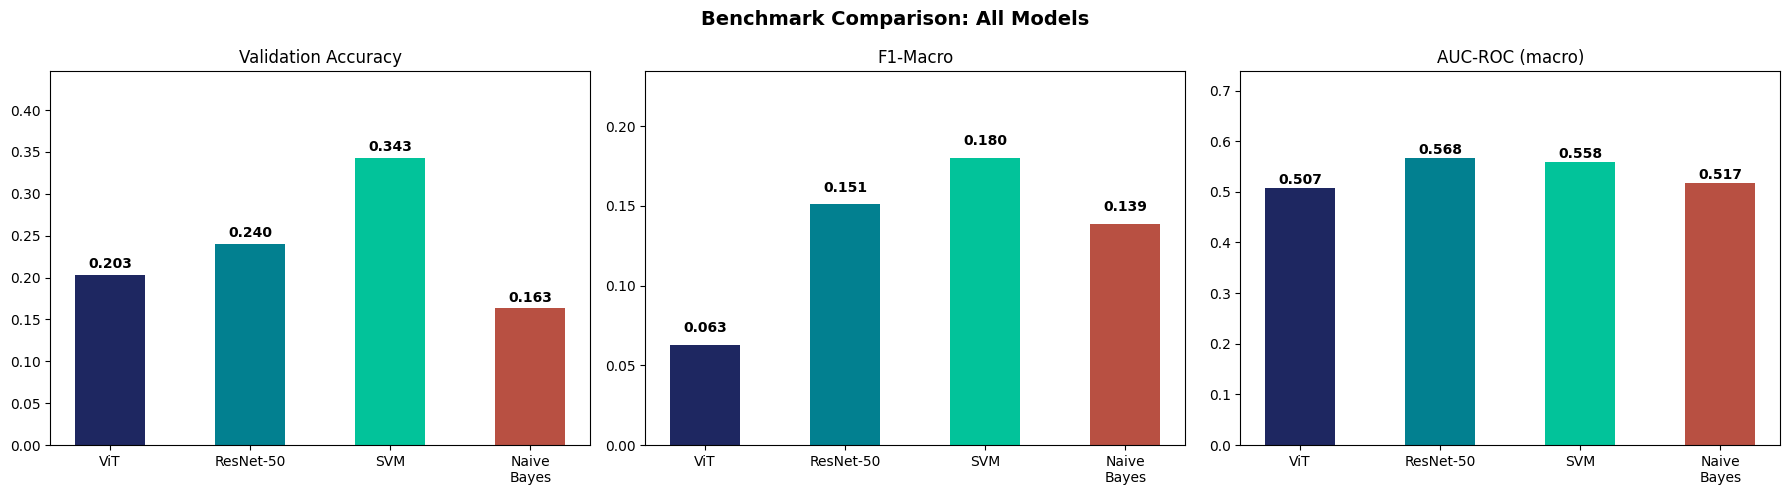

In [26]:
#  Bar Charts
plot_benchmark_comparison(
    results=results,
    save_path="../results/benchmark_comparison.png"
)

## Confusion Matrices
Normalised confusion matrices for ViT and ResNet-50.

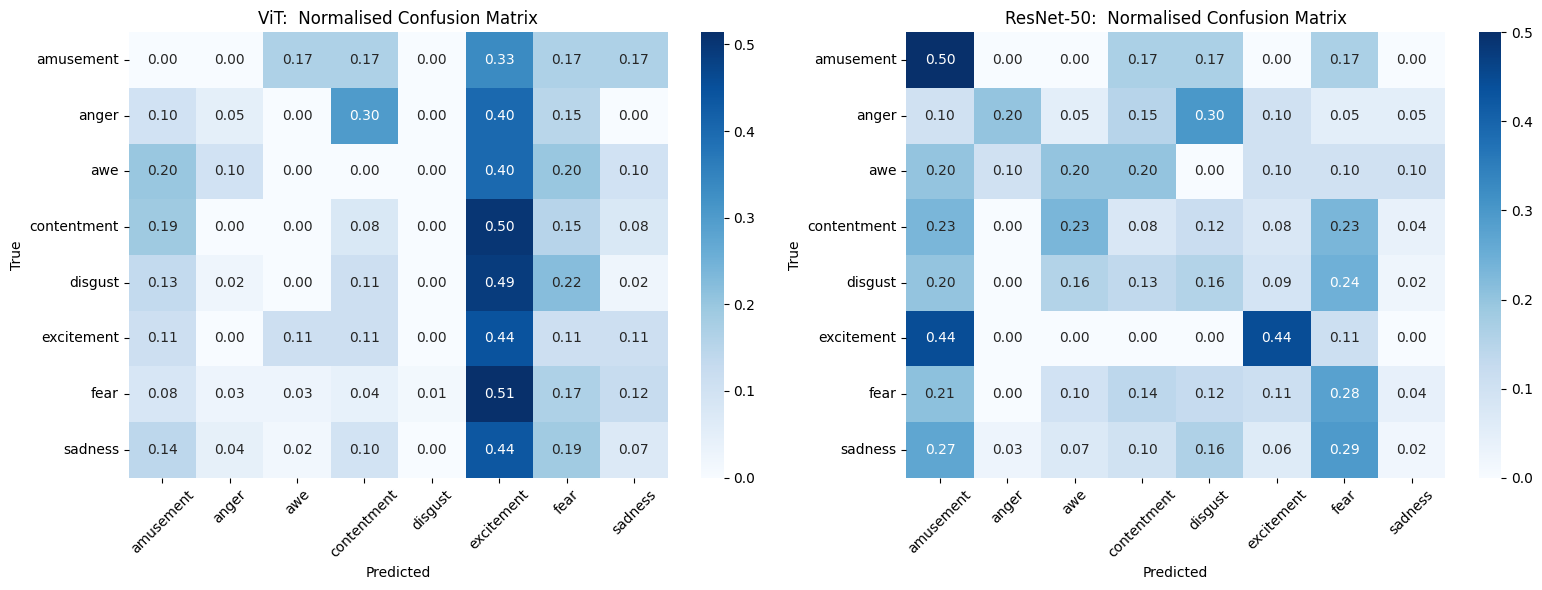

In [27]:
# Plot Confusion Matrices
plot_confusion_matrices(
    labels=all_labels,
    predictions_dict={'ViT': preds_vit, 'ResNet-50': preds_resnet},
    save_path="../results/confusion_matrices.png"
)

## Statistical Test: McNemar's Test
Tests whether the difference between ViT and ResNet-50 is statistically significant.

In [28]:
# McNemar's Test
mcnemar_result = run_mcnemar_test(
    labels=all_labels,
    preds_a=preds_vit,
    preds_b=preds_resnet,
    name_a='ViT',
    name_b='ResNet-50'
)

McNemar's Test: ViT vs ResNet-50
Contingency table:
[[  6  38]
 [ 21 235]]
Statistic: 4.3390
p-value:   0.0372
Statistically significant difference (p < 0.05)


In [29]:
# Save Results
final_results = {
    name: {
        'val_acc': results[name]['val_acc'],
        'f1_macro': results[name]['f1_macro'],
        'auc_roc': results[name]['auc_roc'],
    }
    for name in results
}
final_results['mcnemar'] = {
    'statistic': float(mcnemar_result.statistic),
    'pvalue': float(mcnemar_result.pvalue)
}

with open('../results/final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)

print("Results saved to results/final_results.json")

Results saved to results/final_results.json


## Summary

- All four models evaluated on identical 3k test split (local smoke test)
- Results saved to results/final_results.json
- Plots saved to results/